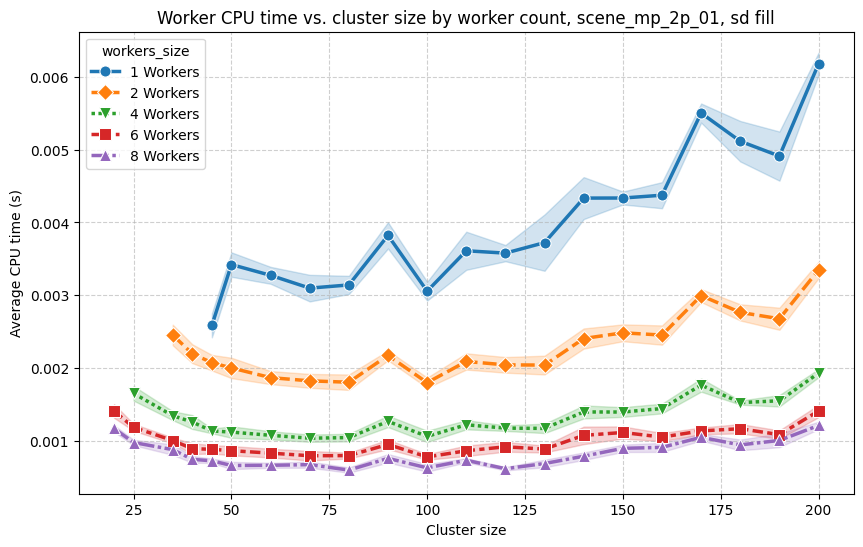

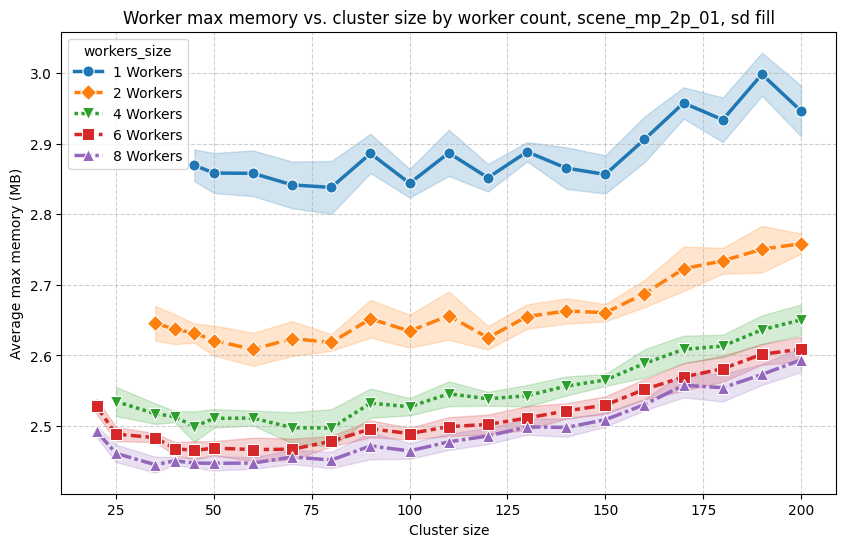

In [14]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the benchmark results
with open('benchmark_results.json', 'r') as f:
    res = json.load(f)

# Parse raw run entries into a pandas DataFrame
records = []
for entry in res['data']:
    c_size = entry['cluster_size']
    w_size = entry['workers_size']
    timings = entry['timings']
    worker_analysis = timings.get('worker_analysis', {})
    
    cpu_times = [v for k, v in worker_analysis.items() if k.endswith('_cpu_time')]
    mem_usages = [v for k, v in worker_analysis.items() if k.endswith('_max_memory_mb')]
    
    if cpu_times and mem_usages:
        records.append({
            'cluster_size': c_size,
            'workers_size': w_size,
            'avg_worker_cpu_time_s': np.mean(cpu_times),
            'max_worker_mem_mb': np.max(mem_usages)
        })

df = pd.DataFrame(records)

# Filter out individual runs where values equal 0
df_cpu = df[df['avg_worker_cpu_time_s'] != 0].copy()
df_mem = df[df['max_worker_mem_mb'] != 0].copy()

# Cast workers_size to string for distinct tab10 color mapping
df_cpu['workers_size'] = df_cpu['workers_size'].astype(str) + " Workers"
df_mem['workers_size'] = df_mem['workers_size'].astype(str) + " Workers"

# Figure 1: Worker CPU Time vs Cluster Size with SD fill
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_cpu, 
    x="cluster_size", 
    y="avg_worker_cpu_time_s", 
    hue="workers_size",
    style="workers_size",                  
    markers=['o', 'D', 'v', 's', '^'], 
    markersize=8,                          
    palette="tab10", 
    linewidth=2.5,
    errorbar='sd',  # <--- Automatically computes and adds the standard deviation fill
    ax=ax1
)
ax1.set_title('Worker CPU time vs. cluster size by worker count, scene_mp_2p_01, sd fill')
ax1.set_xlabel('Cluster size')
ax1.set_ylabel('Average CPU time (s)')
ax1.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Figure 2: Max Worker Memory vs Cluster Size with SD fill
fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_mem, 
    x="cluster_size", 
    y="max_worker_mem_mb", 
    hue="workers_size",
    style="workers_size",                  
    markers=['o', 'D', 'v', 's', '^'], 
    markersize=8,                          
    palette="tab10", 
    linewidth=2.5,
    errorbar='sd',  # <--- Automatically computes and adds the standard deviation fill
    ax=ax2
)
ax2.set_title('Worker max memory vs. cluster size by worker count, scene_mp_2p_01, sd fill')
ax2.set_xlabel('Cluster size')
ax2.set_ylabel('Average max memory (MB)')
ax2.grid(True, linestyle='--', alpha=0.6)
plt.show()

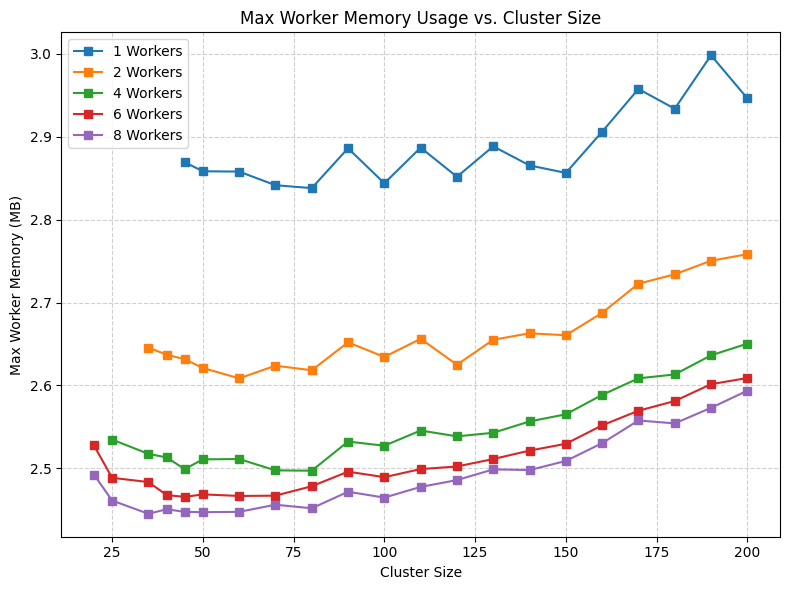

In [ ]:
# Figure 2: Max Worker Memory vs Cluster Size (values equal to 0 removed)
fig2, ax2 = plt.subplots(figsize=(8, 6))
for i, w in enumerate(workers_sizes):
    sub = agg[agg['workers_size'] == w]
    sub_mem = sub[sub['max_mem'] != 0]  # Filter out 0 values
    ax2.plot(sub_mem['cluster_size'], sub_mem['max_mem'], marker='s', color=colors[i], label=f'{w} Workers')

ax2.set_title('Max Worker Memory Usage vs. Cluster Size')
ax2.set_xlabel('Cluster Size')
ax2.set_ylabel('Max Worker Memory (MB)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()
plt.tight_layout()
plt.show()